# TPC-H Collector Demo

# Missing
* connection data beyond loading
* join to connection data
* join to monitoring_single
* connection and configuration also in monitoring and connection df

## Naming
* There is an experiment having a code, say `1775855486`.
* The experiment inspects a SUT, say `PostgreSQL-A`. This is called a `configuration`.
* The experiment is run several times, say twice. The indicator of the run is called `experiment_run`.
* Each run can have several phases as a sequence. The number of the phase is called `client`. The state of the configuration in a phase is called a `connection`.
* Each client can have several `pods`, that are run in parallel. A pod represents a driver.
* Performance metrics are collected per driver pod.  
    The naming of an instance is `<sut>-<experiment_run>-<client>-<pod>`. It is unique per experiment.
* Monitoring metrics are collected per phase. They are automatically aggregated across parallel pods.  
    The naming of an instance is `<sut>-<experiment_run>-<client>`. It is unique per experiment.

## Aggregation
* Aggregation is complicated. Some metrics are aggregated via count, sum, max or average. Others cannot be aggregated sensibly, like experiment code or latency percentiles.
* There are helper functions to aggregated pods that are certainly run in parallel.  
  So `<sut>-<experiment_run>-<client>-<pod>` are aggregated to `<sut>-<experiment_run>-<client>`.
* An exception is multi-tenancy.

## Class `collector`
* constructor `collectors.benchbase(path, codes)`
* evaluator object `evaluate = collect.get_evaluator()`
* dataframe of connection infos `collect.get_connections()`
  * index is name of client
* **monitoring metrics**
  * dataframe of available metrics `collect.df_metrics`
    * index is key of metric
  * dataframe of monitored components `collect.get_monitored_phases()`
    * index is key of component
  * dataframe of aggregated metrics per connection `collect.get_monitoring_single_all()`
    * index is name of client
    * metrics aggregated per code, experiment_run and client
  * dataframe of aggregated metrics per connection and across tenants `collect.get_monitoring_all()`
    * index just enumerates
    * metrics aggregated per code, experiment_run and client and across tenants
  * dataframe of time series for a metric of a connection in an experiment `collect.get_monitoring_timeseries_single(code, metric)`
    * index is name of connection
    * unstacked (wide format)
  * dataframe of time series for a metric in all experiments `collect.get_monitoring_timeseries_all(metric)`
    * index just enumerates
    * stacked (long format)
* **performance metrics**
  * dataframe of loading metrics `collect.get_loading_time_max_all()`
    * index is name of client
  * dataframe of performance aggregated per parallel client `collect.get_performance_all()`
    * index just enumerates
    * performance aggregated per code, experiment_run and client
  * dataframe of performance for one experiment `collect.get_performance_single()`
    * performance of each single client (driver)
    * index is name of client pod
  * dataframe of performance for all experiments `collect.get_performance_all_single()`
    * performance of each single client (driver)
    * index is name of client pod


[1] [Benchmarking Multi-Tenant Architectures in PostgreSQL](https://doi.org/10.48786/edbt.2026.46)
> Erdelt, P.K., and Rabl T. (2026)
> In: Proceedings 29th International Conference on Extending Database Technology, EDBT 2026
> OpenProceedings.org
> https://doi.org/10.48786/edbt.2026.46


In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)
pd.options.display.max_columns = None
pd.options.display.max_rows = None

from bexhoma import collectors

%matplotlib inline

# Functions for Nice Plots

In [2]:
from notebookutils import *

# Collect Results

In [3]:
#path = r"D:\data\benchmarks"
path = r"/data/benchmarks"
filename_prefix = "demo_"
b_plot_save = False
b_skip_plots = True

In [4]:
codes = [
    "1776418956",
    "1776420958"
]

codes

['1776418956', '1776420958']

In [5]:
collect = collectors.default(path, codes)

# Get all Metrics Metadata

## Metrics Names and Types

Metrics that are derived from monitoring

In [6]:
collect.df_metrics

,title,active,type,metric
total_cpu_memory,Memory Usage [MiB],True,cluster,gauge
total_cpu_memory_cached,Memory Usage Cached [MiB],True,cluster,gauge
total_cpu_util,CPU Utilization,True,cluster,gauge
total_cpu_throttled,CPU Throttle,True,cluster,gauge
total_cpu_throttled_s,CPU Throttled Time [s],True,cluster,counter
total_cpu_util_others,CPU Utilization Others,False,cluster,gauge
total_cpu_util_s,CPU Utilization Time [s],True,cluster,counter
total_cpu_util_user_s,CPU User Time [s],True,cluster,counter
total_cpu_util_sys_s,CPU System Time [s],True,cluster,counter
total_cpu_util_others_s,CPU Utilization Time Others [s],False,cluster,counter


## Names of Monitored Phases

Names of components and their phases

In [7]:
collect.get_monitored_components()

,description
loading,Loading phase: SUT deployment
datagenerator,Loading phase: component data generator
loader,Loading phase: component loader
stream,Execution phase: SUT deployment
benchmarker,Execution phase: component benchmarker


# Get Connection Infos

List of states of SUTs, containing loading infos.

In [8]:
df = collect.get_connections()
df.T

,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-1-1,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-2-1,1776420958-PostgreSQL-BHT-8-2-2
code,1776418956,1776418956,1776418956,1776418956,1776420958,1776420958,1776420958,1776420958
connection,PostgreSQL-BHT-8-1-1-1,PostgreSQL-BHT-8-1-2-2,PostgreSQL-BHT-8-2-1-1,PostgreSQL-BHT-8-2-2-2,PostgreSQL-BHT-8-1-1-1,PostgreSQL-BHT-8-1-2-2,PostgreSQL-BHT-8-2-1-1,PostgreSQL-BHT-8-2-2-2
configuration,,,,,,,,
phase,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-1-1,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-2-1,1776420958-PostgreSQL-BHT-8-2-2
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
dockerimage,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3,postgres:18.3
time_load,455.0,455.0,455.0,455.0,1256.0,1256.0,1256.0,1256.0
time_ingest,141.0,141.0,141.0,141.0,350.0,350.0,350.0,350.0
time_check,291.0,291.0,291.0,291.0,843.0,843.0,843.0,843.0


# Get Aggregated Metrics per SUT and per Experiment

In [9]:
df_performance = collect.get_monitoring_aggregated_per_phase("stream")
df_performance.T

,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-1-1,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-2-1,1776420958-PostgreSQL-BHT-8-2-2
Memory Usage [MiB],10919.47,12131.24,10392.28,11955.10,17504.07,19192.60,14054.22,16993.59
Memory Usage Cached [MiB],15835.40,17047.17,15288.83,16789.84,27302.43,28990.96,22555.50,26276.44
CPU Utilization,1.66,3.29,0.96,3.39,2.91,5.70,1.60,5.64
CPU Throttle,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Throttled Time [s],0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CPU Utilization Time [s],180.14,320.88,998.63,395.04,381.59,869.22,2263.06,877.07
CPU User Time [s],156.36,281.35,826.53,344.83,331.65,767.27,1928.57,768.57
CPU System Time [s],23.78,39.53,172.10,50.21,49.94,101.95,334.50,108.51
Network Rx Total [MiB],1.72,7.30,3307.36,1.87,1.91,3.74,6644.39,3.68
Network Tx Total [MiB],0.20,1320.29,21.81,3.35,1.96,3.78,39.78,3.66


In [10]:
df_performance = collect.add_metadata(df_performance)
df_performance.T

combine on index and column 'phase'


phase,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-1-1,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-2-1,1776420958-PostgreSQL-BHT-8-2-2
Memory Usage [MiB],10919.47,12131.24,10392.28,11955.1,17504.07,19192.6,14054.22,16993.59
Memory Usage Cached [MiB],15835.4,17047.17,15288.83,16789.84,27302.43,28990.96,22555.5,26276.44
CPU Utilization,1.66,3.29,0.96,3.39,2.91,5.7,1.6,5.64
CPU Throttle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Throttled Time [s],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Utilization Time [s],180.14,320.88,998.63,395.04,381.59,869.22,2263.06,877.07
CPU User Time [s],156.36,281.35,826.53,344.83,331.65,767.27,1928.57,768.57
CPU System Time [s],23.78,39.53,172.1,50.21,49.94,101.95,334.5,108.51
Network Rx Total [MiB],1.72,7.3,3307.36,1.87,1.91,3.74,6644.39,3.68
Network Tx Total [MiB],0.2,1320.29,21.81,3.35,1.96,3.78,39.78,3.66


# Bar Plots of Aggregated Values per Metric

In [11]:
metric = 'total_cpu_memory'
code = codes[0]
df = collect.get_monitoring_timeseries_per_phase(code, metric=metric)
df.T

,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2
0,9770.968750,10315.593750,10315.644531,10300.511719
1,9770.968750,10315.593750,10315.644531,10300.511719
2,9770.968750,10315.593750,10315.644531,10300.511719
3,9770.968750,10315.593750,10315.644531,10300.511719
4,9770.968750,10315.593750,10315.644531,10300.511719
5,9838.882812,10315.593750,10315.644531,10300.511719
6,9838.882812,10315.593750,10315.644531,10300.511719
7,9838.882812,10315.593750,10315.644531,10300.511719
8,9838.882812,10315.593750,10315.644531,10300.511719
9,9838.882812,10315.593750,10315.644531,10300.511719


In [12]:
df_performance = collect.add_metadata(df)
df_performance.T

combine on index and column 'phase'


phase,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2
0,9770.96875,10315.59375,10315.644531,10300.511719
1,9770.96875,10315.59375,10315.644531,10300.511719
2,9770.96875,10315.59375,10315.644531,10300.511719
3,9770.96875,10315.59375,10315.644531,10300.511719
4,9770.96875,10315.59375,10315.644531,10300.511719
5,9838.882812,10315.59375,10315.644531,10300.511719
6,9838.882812,10315.59375,10315.644531,10300.511719
7,9838.882812,10315.59375,10315.644531,10300.511719
8,9838.882812,10315.59375,10315.644531,10300.511719
9,9838.882812,10315.59375,10315.644531,10300.511719


In [13]:
metric = 'total_cpu_memory'
code = codes[0]
collect.get_monitoring_timeseries_all(metric=metric)

,timestamp,code,phase,experiment_run,client,type_tenants,vol_tenants,num_tenants,metric,component,value
0,0,1776418956,1776418956-PostgreSQL-BHT-8-1-1,1,1,,False,0,total_cpu_memory,stream,9770.968750
1,0,1776418956,1776418956-PostgreSQL-BHT-8-1-2,1,2,,False,0,total_cpu_memory,stream,10315.593750
2,0,1776418956,1776418956-PostgreSQL-BHT-8-2-1,2,1,,False,0,total_cpu_memory,stream,10315.644531
3,0,1776418956,1776418956-PostgreSQL-BHT-8-2-2,2,2,,False,0,total_cpu_memory,stream,10300.511719
4,0,1776420958,1776420958-PostgreSQL-BHT-8-1-1,1,1,,False,0,total_cpu_memory,stream,13877.750000
5,0,1776420958,1776420958-PostgreSQL-BHT-8-1-2,1,2,,False,0,total_cpu_memory,stream,14874.777344
6,0,1776420958,1776420958-PostgreSQL-BHT-8-2-1,2,1,,False,0,total_cpu_memory,stream,14904.285156
7,0,1776420958,1776420958-PostgreSQL-BHT-8-2-2,2,2,,False,0,total_cpu_memory,stream,14743.281250
8,1,1776418956,1776418956-PostgreSQL-BHT-8-1-1,1,1,,False,0,total_cpu_memory,stream,9770.968750
9,1,1776418956,1776418956-PostgreSQL-BHT-8-1-2,1,2,,False,0,total_cpu_memory,stream,10315.593750


In [14]:
df_performance = collect.get_performance_per_connection()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.dropna(inplace=True)
df_performance.T

,1776418956-PostgreSQL-BHT-8-1-1-1,1776418956-PostgreSQL-BHT-8-1-2-1,1776418956-PostgreSQL-BHT-8-1-2-2,1776418956-PostgreSQL-BHT-8-2-1-1,1776418956-PostgreSQL-BHT-8-2-2-1,1776418956-PostgreSQL-BHT-8-2-2-2,1776420958-PostgreSQL-BHT-8-1-1-1,1776420958-PostgreSQL-BHT-8-1-2-1,1776420958-PostgreSQL-BHT-8-1-2-2,1776420958-PostgreSQL-BHT-8-2-1-1,1776420958-PostgreSQL-BHT-8-2-2-1,1776420958-PostgreSQL-BHT-8-2-2-2
total_timer_execution,1.566479,1.597086,1.55034,2.345645,1.588409,1.588487,2.913431,2.934896,2.907257,4.244649,2.986872,2.918278
Power@Size [~Q/h],6894.444445,6762.31504,6966.213449,4604.277867,6799.256171,6798.922785,7413.940216,7359.714573,7429.684303,5088.759517,7231.64457,7401.624895
Geo Times [s],1.566479,1.597086,1.55034,2.345645,1.588409,1.588487,2.913431,2.934896,2.907257,4.244649,2.986872,2.918278
configuration,1776418956--,1776418956--,1776418956--,1776418956--,1776418956--,1776418956--,1776420958--,1776420958--,1776420958--,1776420958--,1776420958--,1776420958--
connection,1776418956-PostgreSQL-BHT-8-1-1-1,1776418956-PostgreSQL-BHT-8-1-2-1,1776418956-PostgreSQL-BHT-8-1-2-2,1776418956-PostgreSQL-BHT-8-2-1-1,1776418956-PostgreSQL-BHT-8-2-2-1,1776418956-PostgreSQL-BHT-8-2-2-2,1776420958-PostgreSQL-BHT-8-1-1-1,1776420958-PostgreSQL-BHT-8-1-2-1,1776420958-PostgreSQL-BHT-8-1-2-2,1776420958-PostgreSQL-BHT-8-2-1-1,1776420958-PostgreSQL-BHT-8-2-2-1,1776420958-PostgreSQL-BHT-8-2-2-2
phase,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2,1776418956-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-1-1,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-2-1,1776420958-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-2-2
SF,3.0,3.0,3.0,3.0,3.0,3.0,6.0,6.0,6.0,6.0,6.0,6.0
experiment_run,1,1,1,2,2,2,1,1,1,2,2,2
client,1,2,2,1,2,2,1,2,2,1,2,2
time [s],58,60,57,120,59,60,113,110,110,210,119,116


In [15]:
df_performance = collect.get_performance_aggregated_per_phase()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

,1776418956-PostgreSQL-BHT-8-1-1-1,1776418956-PostgreSQL-BHT-8-1-2-1,1776418956-PostgreSQL-BHT-8-1-2-2,1776418956-PostgreSQL-BHT-8-2-1-1,1776418956-PostgreSQL-BHT-8-2-2-1,1776418956-PostgreSQL-BHT-8-2-2-2,1776420958-PostgreSQL-BHT-8-1-1-1,1776420958-PostgreSQL-BHT-8-1-2-1,1776420958-PostgreSQL-BHT-8-1-2-2,1776420958-PostgreSQL-BHT-8-2-1-1,1776420958-PostgreSQL-BHT-8-2-2-1,1776420958-PostgreSQL-BHT-8-2-2-2
configuration,1776418956--,1776418956--,1776418956--,1776418956--,1776418956--,1776418956--,1776420958--,1776420958--,1776420958--,1776420958--,1776420958--,1776420958--
experiment_run,1,1,1,2,2,2,1,1,1,2,2,2
phase,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2,1776418956-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-1-1,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-2-1,1776420958-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-2-2
total_timer_execution,1.566479,1.597086,1.55034,2.345645,1.588409,1.588487,2.913431,2.934896,2.907257,4.244649,2.986872,2.918278
Power@Size [~Q/h],6894.444445,6762.31504,6966.213449,4604.277867,6799.256171,6798.922785,7413.940216,7359.714573,7429.684303,5088.759517,7231.64457,7401.624895
code,1776418956,1776418956,1776418956,1776418956,1776418956,1776418956,1776420958,1776420958,1776420958,1776420958,1776420958,1776420958
pod_count,1,1,1,1,1,1,1,1,1,1,1,1
SF,3.0,3.0,3.0,3.0,3.0,3.0,6.0,6.0,6.0,6.0,6.0,6.0
time [s],58,60,57,120,59,60,113,110,110,210,119,116
client,1,2,2,1,2,2,1,2,2,1,2,2


In [16]:
df = collect.add_metadata(df_performance)
df.T


combine on columns phase


,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2,1776418956-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-1-1,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-2-1,1776420958-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-2-2
configuration,1776418956--,1776418956--,1776418956--,1776418956--,1776418956--,1776418956--,1776420958--,1776420958--,1776420958--,1776420958--,1776420958--,1776420958--
experiment_run,1,1,1,2,2,2,1,1,1,2,2,2
phase,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2,1776418956-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-1-1,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-1-2,1776420958-PostgreSQL-BHT-8-2-1,1776420958-PostgreSQL-BHT-8-2-2,1776420958-PostgreSQL-BHT-8-2-2
total_timer_execution,1.566479,1.597086,1.55034,2.345645,1.588409,1.588487,2.913431,2.934896,2.907257,4.244649,2.986872,2.918278
Power@Size [~Q/h],6894.444445,6762.31504,6966.213449,4604.277867,6799.256171,6798.922785,7413.940216,7359.714573,7429.684303,5088.759517,7231.64457,7401.624895
code,1776418956,1776418956,1776418956,1776418956,1776418956,1776418956,1776420958,1776420958,1776420958,1776420958,1776420958,1776420958
pod_count,1,1,1,1,1,1,1,1,1,1,1,1
SF,3.0,3.0,3.0,3.0,3.0,3.0,6.0,6.0,6.0,6.0,6.0,6.0
time [s],58,60,57,120,59,60,113,110,110,210,119,116
client,1,2,2,1,2,2,1,2,2,1,2,2


# Boxplot of All Metrics for a Single Experiment

In [17]:
if not b_skip_plots:
    results = []
    code = codes[0]
    for idx, row in collect.df_metrics.iterrows():
        if row["active"] == False:
            continue
        metric_name = idx
        method = 'diff' if row["metric"] == 'counter' else 'mean'
        col_name = row["title"]
        df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric_name)
        #print(df_monitoring)
        ax = df_monitoring.boxplot()
        ax.set_title(col_name)
        plt.show()

# Boxplot of A Single Metric for a Single Experiment

In [18]:
metric = 'total_cpu_memory'
code = codes[0]
collect.get_monitoring_timeseries_single(code, metric=metric)

,1776418956-PostgreSQL-BHT-8-1-1,1776418956-PostgreSQL-BHT-8-1-2,1776418956-PostgreSQL-BHT-8-2-1,1776418956-PostgreSQL-BHT-8-2-2
0,9770.968750,10315.593750,10315.644531,10300.511719
1,9770.968750,10315.593750,10315.644531,10300.511719
2,9770.968750,10315.593750,10315.644531,10300.511719
3,9770.968750,10315.593750,10315.644531,10300.511719
4,9770.968750,10315.593750,10315.644531,10300.511719
5,9838.882812,10315.593750,10315.644531,10300.511719
6,9838.882812,10315.593750,10315.644531,10300.511719
7,9838.882812,10315.593750,10315.644531,10300.511719
8,9838.882812,10315.593750,10315.644531,10300.511719
9,9838.882812,10315.593750,10315.644531,10300.511719


In [19]:
metric = 'total_cpu_memory'
code = codes[0]
collect.get_monitoring_timeseries_all( metric=metric)

,timestamp,code,phase,experiment_run,client,type_tenants,vol_tenants,num_tenants,metric,component,value
0,0,1776418956,1776418956-PostgreSQL-BHT-8-1-1,1,1,,False,0,total_cpu_memory,stream,9770.968750
1,0,1776418956,1776418956-PostgreSQL-BHT-8-1-2,1,2,,False,0,total_cpu_memory,stream,10315.593750
2,0,1776418956,1776418956-PostgreSQL-BHT-8-2-1,2,1,,False,0,total_cpu_memory,stream,10315.644531
3,0,1776418956,1776418956-PostgreSQL-BHT-8-2-2,2,2,,False,0,total_cpu_memory,stream,10300.511719
4,0,1776420958,1776420958-PostgreSQL-BHT-8-1-1,1,1,,False,0,total_cpu_memory,stream,13877.750000
5,0,1776420958,1776420958-PostgreSQL-BHT-8-1-2,1,2,,False,0,total_cpu_memory,stream,14874.777344
6,0,1776420958,1776420958-PostgreSQL-BHT-8-2-1,2,1,,False,0,total_cpu_memory,stream,14904.285156
7,0,1776420958,1776420958-PostgreSQL-BHT-8-2-2,2,2,,False,0,total_cpu_memory,stream,14743.281250
8,1,1776418956,1776418956-PostgreSQL-BHT-8-1-1,1,1,,False,0,total_cpu_memory,stream,9770.968750
9,1,1776418956,1776418956-PostgreSQL-BHT-8-1-2,1,2,,False,0,total_cpu_memory,stream,10315.593750


In [20]:
if not b_skip_plots:
    metric = 'pg_stat_activity_max_tx_duration_active'
    #metric = 'pg_stat_database_blks_reads'
    #metric = 'pg_stat_activity_count_idle_transaction'
    metric = 'total_cpu_memory'
    code = codes[0]
    df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)
    ax = df_monitoring.boxplot()
    ax.set_title(collect.df_metrics.loc[metric]['title'])#metric)
    plt.show()
    df_monitoring

# Lineplot of a Single Metric for a Single Experiment

In [21]:
if not b_skip_plots:
    code = codes[0]
    metric = 'pg_stat_database_blks_hit'
    metric = 'pg_stat_activity_count_idle_transaction'
    metric = 'total_cpu_memory'
    metric = 'total_cpu_util'
    metric = 'total_cpu_util_s'
    metric = 'core_variance'
    df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)
    ax = df_monitoring.plot()
    ax.set_title(metric)
    plt.show()
    #df_monitoring

# Boxplot of a Single Metric for all Experiments

In [22]:
metric = 'pg_stat_database_blks_hit'
metric = 'pg_stat_activity_count_idle_transaction'
metric = 'total_cpu_memory'
metric = 'total_cpu_util'
metric = 'total_cpu_util_s'
metric = 'core_variance'
metric = 'pg_locks_count_exclusivelock'
metric = 'pg_stat_activity_count_active'
df_performance = collect.get_monitoring_timeseries_all(metric)
#df_performance
df_performance_first = df_performance[df_performance['client']=="1"]
#df_performance_first
df_performance_second = df_performance[df_performance['client']=="2"]
#df_performance_second
#df_performance_first['value'].describe()
#df_performance

## First Execution Run

/home/perdelt/Git-projects/Benchmark-Experiment-Host-Manager/dev/notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
/home/perdelt/Git-projects/Benchmark-Experiment-Host-Manager/dev/notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


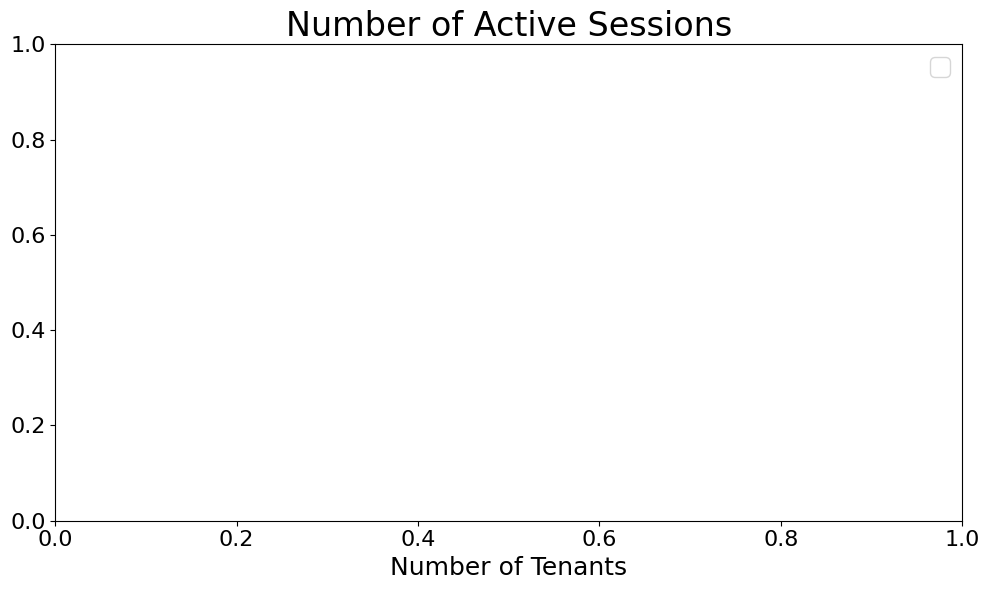

In [23]:
plot_boxplots(df_performance_first, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Second Execution Run

/home/perdelt/Git-projects/Benchmark-Experiment-Host-Manager/dev/notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
/home/perdelt/Git-projects/Benchmark-Experiment-Host-Manager/dev/notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


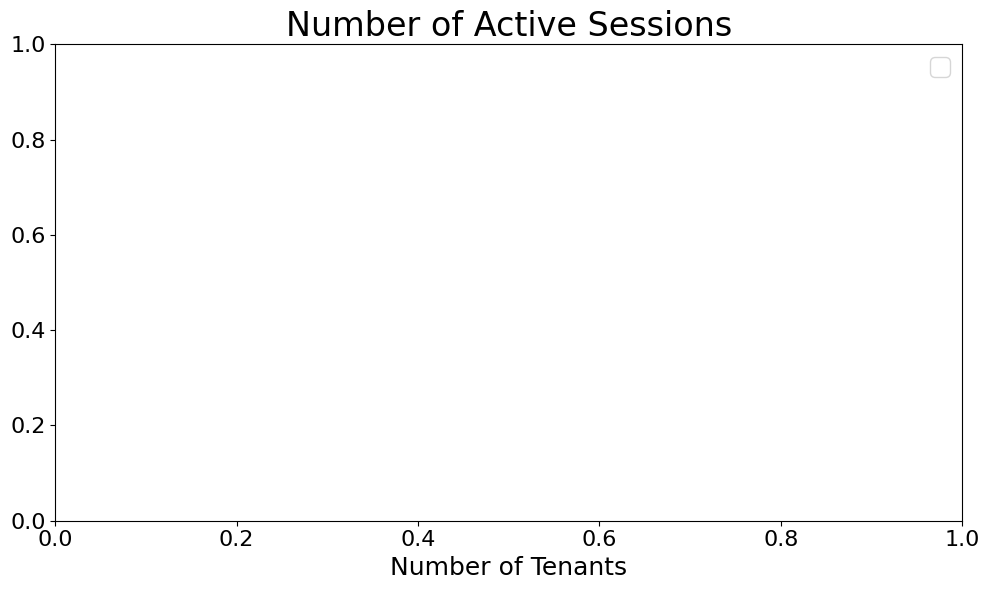

In [24]:
plot_boxplots(df_performance_second, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Lineplot of a Single Metric for All Experiments

## First Execution Run

/home/perdelt/Git-projects/Benchmark-Experiment-Host-Manager/dev/notebookutils.py:187: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(


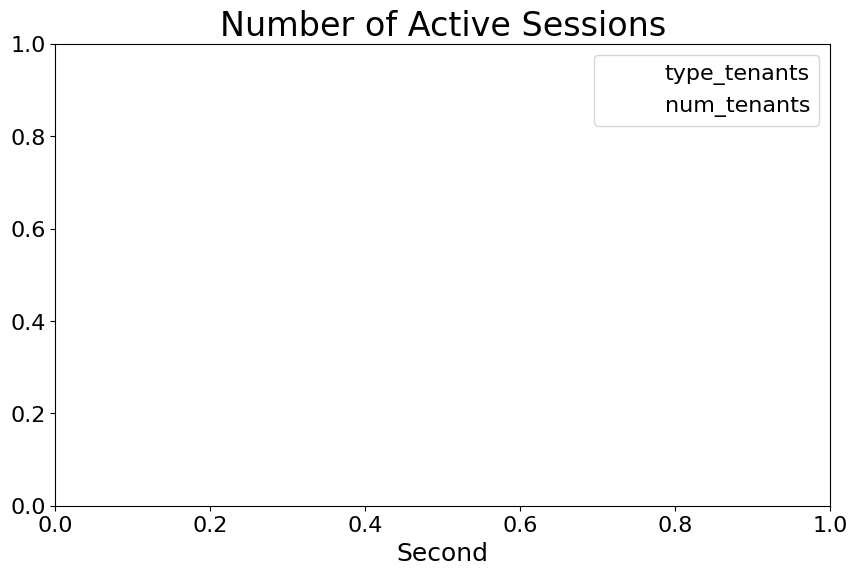

In [25]:
#df = df_performance_first[df_performance_first['type'] == 'None']
#df = df[df['experiment_run'] == '1']
plot_lines(df_performance_first, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)
#df

# Aggregated Metrics for all Connections

In [26]:
df_performance = collect.get_monitoring_single_all("stream")
df_performance.T

AttributeError: 'default' object has no attribute 'get_monitoring_single_all'

# Monitoring Aggregated Values

In [ ]:
df_performance = collect.get_monitoring_all("stream")

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T#[['Max CPU', 'client', 'type', 'num_tenants']]

## First Execution Run

In [ ]:
plot_bars(df_performance_first, y='Buffer Cache Hit Ratio', title='Cache Hit Ratio [%]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Second Execution Run

In [ ]:
plot_bars(df_performance_second, y='Buffer Cache Hit Ratio', title='Cache Hit Ratio [%]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Performance Results per Tenant

In [ ]:
df_performance = collect.get_performance_all_single()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

## First Execution Run

In [ ]:
plot_boxplots(df_performance_first, y='Goodput (requests/second)', title='Distribution of Goodput First Run [req/s]', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_boxplots(df_performance_second, y='Goodput (requests/second)', title='Distribution of Goodput Second Run [req/s]', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_boxplots(df_performance_first, y='Latency Distribution.99th Percentile Latency (microseconds)', title=r'Distribution of 99th Latency 1st Run [$\mu s$]', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_boxplots(df_performance_second, y='Latency Distribution.99th Percentile Latency (microseconds)', title=r'Distribution of 99th Latency 2nd Run [$\mu s$]', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Performance Results per Total

In [ ]:
collect.get_performance_single().T

In [ ]:
collect.get_performance_all_single().T

In [ ]:
df_performance = collect.get_performance_all()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.dropna(inplace=True)

In [ ]:
df_performance.T

In [ ]:
import seaborn as sns

sns.barplot(data=df_performance, x='experiment_run', y='Goodput (requests/second)', hue='client')
plt.show()


In [ ]:
plot_bars(df_performance, y='Goodput (requests/second)', title='Goodput [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='Goodput (requests/second)', title='Goodput First Run [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_second, y='Goodput (requests/second)', title='Goodput Second Run [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency First Run [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_second, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency Second Run [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='num_errors', title='Deadlocks', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
df_performance = collect.get_loading_time_max_all()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance

In [ ]:
df_performance_first = df_performance[df_performance['client'] == 1]
# Divide datadisk by the count of rows with the same type and num_tenants
df = df_performance_first.copy()
# Create a mask for rows where type is not "container"
mask = df['type'] != 'container'

# Only apply the group count to the relevant rows
group_counts = df[mask].groupby(['type', 'num_tenants'])['datadisk'].transform('count')

# Initialize the column with NaN (or 0, if preferred)
df['datadisk_normalized'] = df['datadisk'] / 1024

# Apply the normalized value only where the mask is True
df.loc[mask, 'datadisk_normalized'] = df.loc[mask, 'datadisk'] / group_counts / 1024

plot_bars(df, y='datadisk_normalized', title='Database Size [GB]', estimator='sum', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='datadisk', title='Database Size [MB]', estimator='sum', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='time_ingest', title='Time for Ingestion [s]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='time_check', title='Time for Vacuum [s]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Hardware Monitoring for Benchmarking Phase

In [ ]:
df_performance = collect.get_monitoring_all(type="stream")

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

In [ ]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='CPU Utilization Time [s]', title='CPU 1st Run [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_second, y='CPU Utilization Time [s]', title='CPU 2nd Run [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='CPU Utilization', title='CPU Utilization [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Custom Aggregation

In [ ]:
metric = 'total_cpu_util'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
plot_bars(df_agg, y='value', title='Max CPU Utilization [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)
#df_agg

In [ ]:
plot_bars(df_performance, y='CPU Throttle', title='CPU Throttle [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Custom Aggregation and Scale

In [ ]:
metric = 'total_cpu_memory'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
df_agg['value'] = df_agg['value'] / 1024.
plot_bars(df_agg, y='value', title='Max Memory Usage [GiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

plot_bars(df_performance, y='Memory Usage [MiB]', title='Average Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
metric = 'total_cpu_memory_cached'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
df_agg['value'] = df_agg['value'] / 1024.
plot_bars(df_agg, y='value', title='Max Memory Usage Cached [GiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Average Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Hardware Monitoring for Loading Phase

In [ ]:
df_performance = collect.get_monitoring_all("loading")

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance_first

In [ ]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='Memory Usage [MiB]', title='Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Efficiency

In [ ]:
client = 1

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

In [ ]:
plot_bars(merged_df, y='E_Lat', title='1st run - $E_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
#plot_bars(merged_df, y='I_Lat', title='1st run - $I_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(merged_df, y='E_Tpx', title='1st run - $E_{Tpx}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(merged_df, y='E_RAM', title='1st run - $E_{RAM}$', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
client = 2

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['CPUs/Request'] = merged_df['CPU [CPUs]'] / merged_df['Goodput (requests/second)'] / 600.
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']

merged_df

In [ ]:
plot_bars(merged_df, y='E_Lat', title='2nd run - $E_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(merged_df, y='E_Tpx', title='2nd run - $E_{Tpx}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(merged_df, y='E_RAM', title='2nd run - $E_{RAM}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
#zip_all_results()